# Alaska: point source vs finite fault travel times

Comparison of first-arrival tsunami travel time maps for a hypothetical
rupture on the Alaska-Aleutian subduction zone computed two ways:

- **Point source** — a single origin at the centroid of the rupture area,
  fanned with rays in all directions.
- **Finite fault** — the rupture area is discretised into a grid of
  sub-sources; each sub-source fans its own rays and the minimum travel
  time across all sub-sources is taken at every grid point.

**Bathymetry:** GEBCO-derived 4 arc-minute grid (`data/NE_pacific_4arcmin.nc`),
covering 180–260°E / 10–65°N (plotted here as 180–100°W).

> **Note:** this notebook requires `scipy` and `netCDF4` in addition to the
> core TsunamiTrace dependencies.  Install with
> `pip install -e ".[examples]"`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import TsunamiTrace as tt
%matplotlib inline

## Load bathymetry

The NetCDF file stores longitudes in the 0–360° convention (180–260°E for
this domain).  We shift them to the more familiar –180 to –100°W range
for plotting; the shifted array is passed to `trace_rays` as well since
the ray integrator only requires the grid to be uniformly spaced and
ascending.

In [2]:
print('Loading data/NE_pacific_4arcmin.nc ...', end='', flush=True)
lon_arr, lat_arr, depth_tracing = tt.load_bathymetry('../data/NE_pacific_4arcmin.nc')
print(' done.')

n_lon, n_lat = depth_tracing.shape
print(f'Grid    : {n_lon} x {n_lat}  (spacing {lon_arr[1]-lon_arr[0]:.4f} deg)')
print(f'Lon     : {lon_arr[0]:.2f} to {lon_arr[-1]:.2f} deg E')
print(f'Lat     : {lat_arr[0]:.2f} to {lat_arr[-1]:.2f} deg N')
print(f'Depth   : {depth_tracing[depth_tracing>0].min():.0f} to {depth_tracing.max():.0f} m ocean')

# Shift longitudes to -180/180 convention for plotting and ray tracing
lon_arr  = lon_arr - 360.0          # 180-260 E  ->  -180 to -100 W

# depth_grid for plotting: (n_lat, n_lon), geographic sign (negative = ocean)
depth_grid = -depth_tracing.T

print(f'Lon (W) : {lon_arr[0]:.2f} to {lon_arr[-1]:.2f} deg')

Loading data/NE_pacific_4arcmin.nc ... done.
Grid    : 1200 x 825  (spacing 0.0667 deg)
Lon     : 180.03 to 259.97 deg E
Lat     : 10.03 to 64.97 deg N
Depth   : 0 to 7720 m ocean
Lon (W) : -179.97 to -100.03 deg


## Bathymetry and topography, quick plot to check all is good

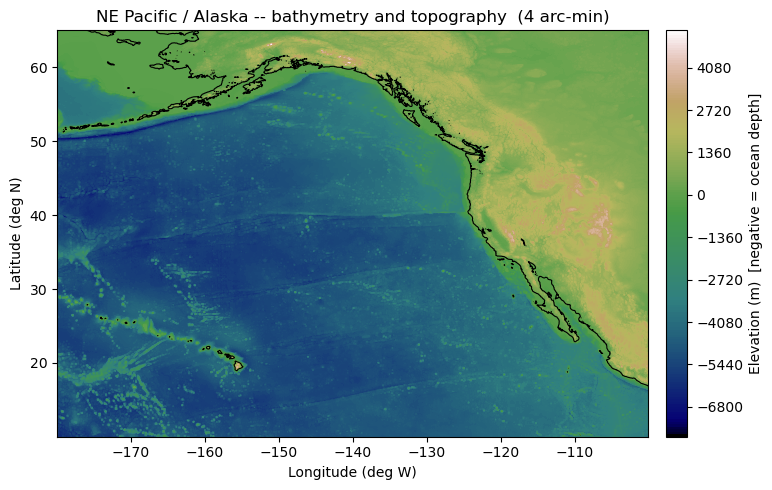

In [3]:
vmin = float(np.nanmin(depth_grid))
vmax = float(np.nanmax(depth_grid))
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))

fig, ax = plt.subplots(figsize=(10, 5))

cf = ax.contourf(lon_arr, lat_arr, depth_grid,
                 levels=200, cmap='gist_earth', norm=norm)

# Coastline at sea level
ax.contour(lon_arr, lat_arr, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

ax.set_xlabel('Longitude (deg W)')
ax.set_ylabel('Latitude (deg N)')
ax.set_title('NE Pacific / Alaska -- bathymetry and topography  (4 arc-min)')
ax.set_aspect('equal')

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Elevation (m)  [negative = ocean depth]')
plt.tight_layout()
plt.show()

## Tsunami ray tracing, point source first

As in the Cascadia example we fan rays at a small azimuth spacing from the source. We are looking at longer trans-oceanic propagation so now we integrate for 12 hours.

The epicenter of the 1964 earthquake was onshore, we nudge it offshore for this example

In [4]:
# 1964 Alaska earthquake epicenter, nudged offshore
SOURCE_LON = -146.680926
SOURCE_LAT =  60.070651


#Ray tracing parameters
DT           =  180.0                        # integration time step, seconds
MAX_TIME     = 11 * 3600.0                    # maximum integration time, seconds
DELTA_DEG = 1e-4
AZIMUTHS_DEG = np.arange(0, 360, DELTA_DEG, dtype=float)

print(f'Source   : {SOURCE_LON}°E, {SOURCE_LAT}°N')
print(f'Rays     : {len(AZIMUTHS_DEG)}  (every {AZIMUTHS_DEG[1]-AZIMUTHS_DEG[0]:.3f}°)')
print(f'dt       : {DT:.0f} s    max time : {MAX_TIME/3600:.0f} h')
print(f'Tracing …', end='', flush=True)

ray_lon, ray_lat, _ = tt.trace_rays(
    lon_arr, lat_arr, depth_tracing,
    DT, MAX_TIME,
    SOURCE_LON, SOURCE_LAT,
    AZIMUTHS_DEG,
)

n_done = int(np.sum(~np.isnan(ray_lon[:, -1])))
print(f'  done.  {n_done}/{len(AZIMUTHS_DEG)} rays reached max_time.')

Source   : -146.680926°E, 60.070651°N
Rays     : 3600000  (every 0.000°)
dt       : 180 s    max time : 11 h
Tracing …  done.  3489/3600000 rays reached max_time.


## Map of all the rays to check ray tracing was successful

/var/folders/5x/5xtm6r7126g41vdgwb462xp40000gn/T/ipykernel_49267/3782640423.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/dmelgarm/opt/anaconda3/envs/tsunamitrace/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


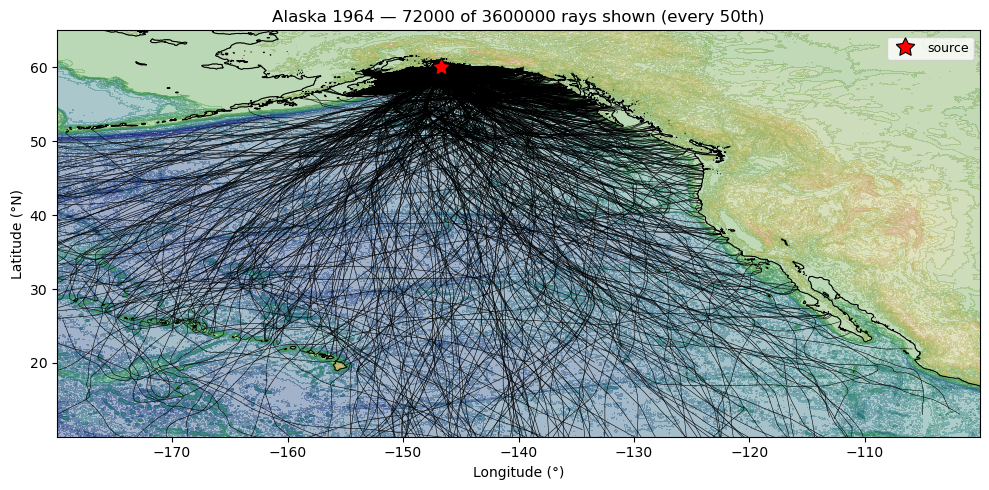

In [5]:
PLOT_EVERY_N = 50   # plot every Nth ray — increase to declutter, 1 = all rays

fig, ax = plt.subplots(figsize=(10, 5))

# Muted bathymetry background
ax.contourf(lon_arr, lat_arr, depth_grid,
            levels=50, cmap='gist_earth', norm=norm, alpha=0.4)
ax.contour(lon_arr, lat_arr, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Ray paths (decimated)
for i in range(0, ray_lon.shape[0], PLOT_EVERY_N):
    ax.plot(ray_lon[i], ray_lat[i], color='black', linewidth=0.4, alpha=1)

# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'Alaska 1964 — {ray_lon.shape[0] // PLOT_EVERY_N} of {ray_lon.shape[0]} rays shown '
    f'(every {PLOT_EVERY_N}th)'
)
ax.set_xlim([lon_arr.min(),lon_arr.max()])
ax.set_ylim([lat_arr.min(),lat_arr.max()])
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Compute the travel times on a regular grid and plot

In [6]:
#Resoltuion of travel time grid
BIN_DEG = 0.4

print('Gridding travel times …', end='', flush=True)
lon_bin, lat_bin, travel_time = tt.grid_travel_times(
    ray_lon, ray_lat, DT,
    lon_arr, lat_arr, depth_tracing,
    bin_deg=BIN_DEG,
)
print(f' done.  Output grid: {len(lon_bin)} × {len(lat_bin)}')

Gridding travel times … done.  Output grid: 201 × 139


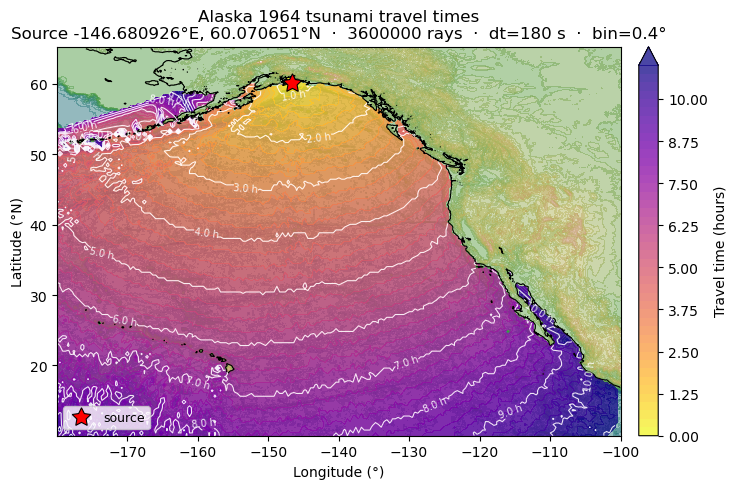

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

# Full-resolution bathymetry background
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))
ax.contourf(lon_arr, lat_arr, depth_grid,
            levels=50, cmap='gist_earth', norm=norm, alpha=0.5)
ax.contour(lon_arr, lat_arr, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Travel time — filled contours on the coarser BIN_DEG grid
tt_max = MAX_TIME / 3600
cf = ax.contourf(lon_bin, lat_bin, travel_time,
                 levels=np.arange(0, tt_max + 0.25, 0.25),
                 cmap='plasma_r', alpha=0.75, extend='max')

# Isochrone lines every 60 minutes
cs = ax.contour(lon_bin, lat_bin, travel_time,
                levels=np.arange(1, tt_max + 1, 1),
                colors='white', linewidths=0.8, alpha=0.9)
ax.clabel(cs, fmt='%.1f h', fontsize=7, inline=True)

# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'Alaska 1964 tsunami travel times\n'
    f'Source {SOURCE_LON}°E, {SOURCE_LAT}°N  ·  '
    f'{len(AZIMUTHS_DEG)} rays  ·  dt={DT:.0f} s  ·  bin={BIN_DEG}°'
)
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='lower left')

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Travel time (hours)')
plt.tight_layout()
plt.show()

## Finite-fault source grid

The rupture area of the 1964 earthquake is outlined in `data/1964_slip_region.txt`.
We place a regular grid of sub-sources at `DELTA_SOURCE_DEG` spacing and keep only
those that fall inside the polygon.  Each sub-source will later fan its own ray set;
`trace_rays` integrates all of them in a single vectorised pass and `grid_travel_times`
automatically keeps the minimum (first) arrival time across all sub-sources.

In [8]:
from matplotlib.path import Path

# Load the 1964 rupture polygon (lon, lat  tab-separated, comment lines start with #)
slip_poly = np.loadtxt('../data/1964_slip_region.txt', comments='#')
poly_lon  = slip_poly[:, 0]
poly_lat  = slip_poly[:, 1]

# Regular candidate grid covering the polygon bounding box
DELTA_SOURCE_DEG = 0.4
lon_cand = np.arange(poly_lon.min(), poly_lon.max() + DELTA_SOURCE_DEG, DELTA_SOURCE_DEG)
lat_cand = np.arange(poly_lat.min(), poly_lat.max() + DELTA_SOURCE_DEG, DELTA_SOURCE_DEG)
LON_CAND, LAT_CAND = np.meshgrid(lon_cand, lat_cand)
candidates = np.column_stack([LON_CAND.ravel(), LAT_CAND.ravel()])

# Keep only points inside the rupture polygon
poly_path = Path(np.column_stack([poly_lon, poly_lat]))
inside    = poly_path.contains_points(candidates)
src_lons  = candidates[inside, 0]
src_lats  = candidates[inside, 1]

print(f'Candidate grid  : {len(lon_cand)} x {len(lat_cand)} = {len(candidates)} points')
print(f'Inside polygon  : {inside.sum()} sub-sources')
print(f'Lon range       : {src_lons.min():.2f} to {src_lons.max():.2f} °')
print(f'Lat range       : {src_lats.min():.2f} to {src_lats.max():.2f} °')

Candidate grid  : 26 x 14 = 364 points
Inside polygon  : 149 sub-sources
Lon range       : -153.04 to -143.84 °
Lat range       : 56.43 to 60.83 °


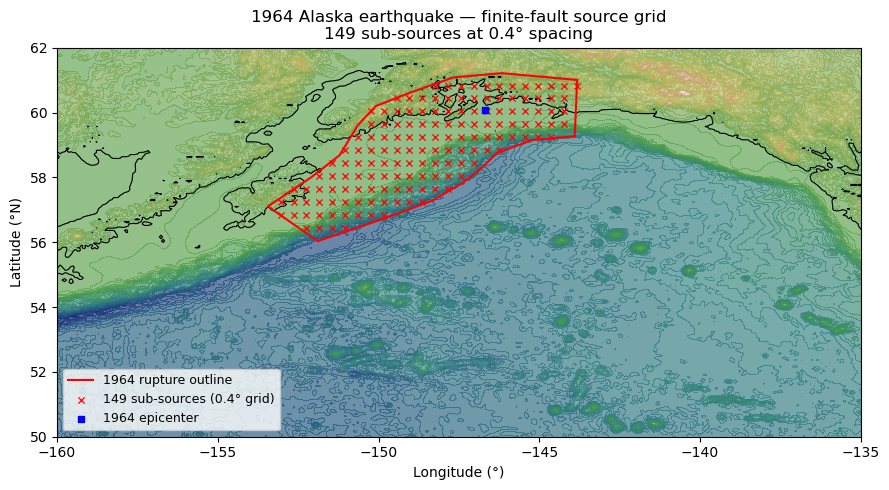

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

# Bathymetry background — zoom to Alaska / Gulf of Alaska
norm_ak = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))
ax.contourf(lon_arr, lat_arr, depth_grid,
            levels=100, cmap='gist_earth', norm=norm_ak, alpha=0.65)
ax.contour(lon_arr, lat_arr, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Rupture polygon outline (close it by appending first vertex)
ax.plot(np.append(poly_lon, poly_lon[0]),
        np.append(poly_lat, poly_lat[0]),
        color='red', linewidth=1.5, zorder=4, label='1964 rupture outline')

# Sub-source grid
ax.scatter(src_lons, src_lats,
           marker='x', s=20, c='red', linewidths=0.9,
           zorder=5, label=f'{len(src_lons)} sub-sources ({DELTA_SOURCE_DEG}° grid)')

ax.scatter(SOURCE_LON,SOURCE_LAT,
           marker='s',s=20,c='blue',
           zorder=6,label='1964 epicenter')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'1964 Alaska earthquake — finite-fault source grid\n'
    f'{len(src_lons)} sub-sources at {DELTA_SOURCE_DEG}° spacing'
)
ax.set_xlim([-160, -135])
ax.set_ylim([ 50,   62])
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

## Finite-fault ray tracing

Each sub-source fans rays in all directions; `trace_rays` integrates all sources
simultaneously in a single vectorised RK4 pass and returns a
`(n_sources, n_azimuths, n_steps)` array.  A coarser azimuth spacing than the
point-source case (1° vs 0.001°) is used because the many distributed sources
already provide dense spatial coverage of the wavefield.

In [10]:
# Azimuth fan — coarser than point source; source density compensates
AZIMUTHS_FF = np.arange(0, 360, 0.05, dtype=float)   # 360 rays per sub-source

n_total_rays = len(src_lons) * len(AZIMUTHS_FF)
print(f'Sub-sources      : {len(src_lons)}')
print(f'Azimuths/source  : {len(AZIMUTHS_FF)}  (every 1°)')
print(f'Total rays       : {n_total_rays:,}')
print(f'dt               : {DT:.0f} s    max time : {MAX_TIME/3600:.0f} h')
print('Tracing ...', end='', flush=True)

# trace_rays returns (n_sources, n_azimuths, n_steps) for array sources
ray_lon_ff, ray_lat_ff, _ = tt.trace_rays(
    lon_arr, lat_arr, depth_tracing,
    DT, MAX_TIME,
    src_lons, src_lats,
    AZIMUTHS_FF,
)

print(f'  done.  Output shape: {ray_lon_ff.shape}')
n_done_ff = int(np.sum(~np.isnan(ray_lon_ff[:, :, -1])))
print(f'Rays that reached max_time: {n_done_ff:,} / {n_total_rays:,}')

Sub-sources      : 149
Azimuths/source  : 7200  (every 1°)
Total rays       : 1,072,800
dt               : 180 s    max time : 11 h
Tracing ...  done.  Output shape: (149, 7200, 222)
Rays that reached max_time: 3,340 / 1,072,800


## Finite-fault travel time map

`grid_travel_times` expects a 2-D `(n_rays, n_steps)` array, so we flatten the
source and azimuth axes before calling it.  Because `binned_statistic_2d` uses
`statistic='min'`, the minimum travel time across all sub-sources is kept in
each geographic cell automatically — no extra reduction step needed.

Gridding travel times ... done.  Output grid: 201 x 139


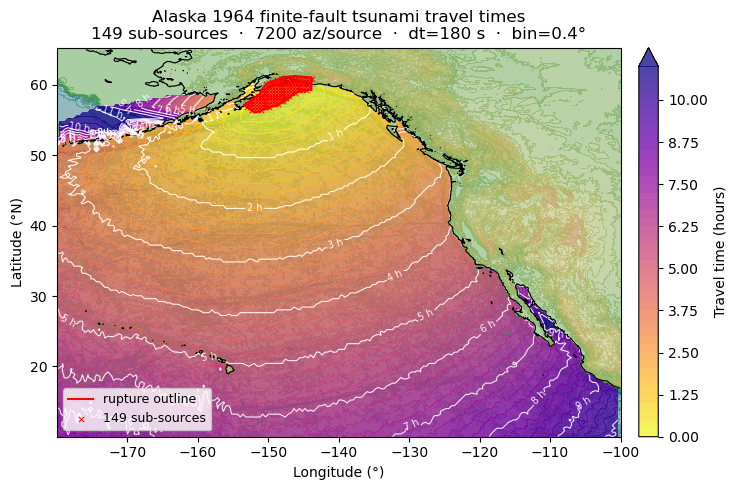

In [11]:
# Flatten (n_sources, n_azimuths, n_steps) → (n_sources*n_azimuths, n_steps)
n_src, n_az, n_st = ray_lon_ff.shape
ray_lon_flat = ray_lon_ff.reshape(n_src * n_az, n_st)
ray_lat_flat = ray_lat_ff.reshape(n_src * n_az, n_st)

print('Gridding travel times ...', end='', flush=True)
lon_bin_ff, lat_bin_ff, travel_time_ff = tt.grid_travel_times(
    ray_lon_flat, ray_lat_flat, DT,
    lon_arr, lat_arr, depth_tracing,
    bin_deg=BIN_DEG,
)
print(f' done.  Output grid: {len(lon_bin_ff)} x {len(lat_bin_ff)}')

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))
ax.contourf(lon_arr, lat_arr, depth_grid,
            levels=50, cmap='gist_earth', norm=norm, alpha=0.5)
ax.contour(lon_arr, lat_arr, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Travel time filled contours
tt_max = MAX_TIME / 3600
cf = ax.contourf(lon_bin_ff, lat_bin_ff, travel_time_ff,
                 levels=np.arange(0, tt_max + 0.25, 0.25),
                 cmap='plasma_r', alpha=0.75, extend='max')

# Isochrone lines every hour
cs = ax.contour(lon_bin_ff, lat_bin_ff, travel_time_ff,
                levels=np.arange(1, tt_max + 1, 1),
                colors='white', linewidths=0.8, alpha=0.9)
ax.clabel(cs, fmt='%.0f h', fontsize=7, inline=True)

# Rupture polygon and sub-sources
ax.plot(np.append(poly_lon, poly_lon[0]),
        np.append(poly_lat, poly_lat[0]),
        color='red', linewidth=1.5, zorder=4, label='rupture outline')
ax.scatter(src_lons, src_lats,
           marker='x', s=15, c='red', linewidths=0.7, zorder=5,
           label=f'{len(src_lons)} sub-sources')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'Alaska 1964 finite-fault tsunami travel times\n'
    f'{len(src_lons)} sub-sources  ·  {len(AZIMUTHS_FF)} az/source  ·  '
    f'dt={DT:.0f} s  ·  bin={BIN_DEG}°'
)
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='lower left')

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Travel time (hours)')
plt.tight_layout()
plt.show()

## Those are clearly different, let's plot the difference between fionite fault and point source travel times

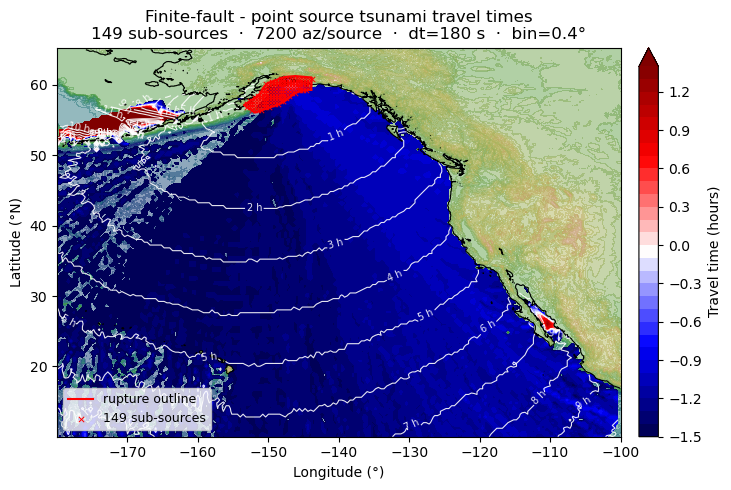

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))
ax.contourf(lon_arr, lat_arr, depth_grid,
            levels=50, cmap='gist_earth', norm=norm, alpha=0.5)
ax.contour(lon_arr, lat_arr, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Travel time filled contours
tt_max = MAX_TIME / 3600
cf = ax.contourf(lon_bin_ff, lat_bin_ff, travel_time_ff-travel_time,
                 levels=np.arange(-1.5, 1.5 , 0.1),
                 cmap='seismic', alpha=1, extend='max')

# Isochrone lines every hour
cs = ax.contour(lon_bin_ff, lat_bin_ff, travel_time_ff,
                levels=np.arange(1, tt_max + 1, 1),
                colors='white', linewidths=0.8, alpha=0.9)
ax.clabel(cs, fmt='%.0f h', fontsize=7, inline=True)

# Rupture polygon and sub-sources
ax.plot(np.append(poly_lon, poly_lon[0]),
        np.append(poly_lat, poly_lat[0]),
        color='red', linewidth=1.5, zorder=4, label='rupture outline')
ax.scatter(src_lons, src_lats,
           marker='x', s=15, c='red', linewidths=0.7, zorder=5,
           label=f'{len(src_lons)} sub-sources')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(
    f'Finite-fault - point source tsunami travel times\n'
    f'{len(src_lons)} sub-sources  ·  {len(AZIMUTHS_FF)} az/source  ·  '
    f'dt={DT:.0f} s  ·  bin={BIN_DEG}°'
)
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='lower left')

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Travel time (hours)')
plt.tight_layout()
plt.show()

#### White contours are the total finite fault travel time and the colors are the difference between FF and point source. Looks like a big difference, up to 1+ hrs! The fact the values are primarily negative values mean the tsunami in the finite fault approximation arrives BEFORE the point source.